## Libraries

In [69]:
#Import necessary Libraries
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
#To suppress warnings
import warnings
warnings.filterwarnings("ignore") 
 #To make sure the plot are shown
%matplotlib inline

## Datasets

In [47]:
#Load Datasets
pizza = pd.read_csv("pizzas.csv")
pizza_types = pd.read_csv("pizza_types.csv",encoding="latin1")
orders = pd.read_csv("orders.csv")
order_details = pd.read_csv("order_details.csv")

In [48]:
pizza_data = pd.merge(pizza,pizza_types,on="pizza_type_id",how="inner")

In [49]:
order_data = pd.merge(orders,order_details,on="order_id",how="inner")

In [50]:
df = pd.merge(pizza_data,order_data,on="pizza_id",how="inner") #Merge the datasets on the pizza_id column to be able to analize together

In [51]:
df.head() # Printing out the first five in the dataframe

,pizza_id,pizza_type_id,size,price,name,category,ingredients,order_id,date,time,order_details_id,quantity
0,bbq_ckn_s,bbq_ckn,S,12.75,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,...",6,2015-01-01,12:29:36,11,1
1,bbq_ckn_s,bbq_ckn,S,12.75,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,...",102,2015-01-02,17:54:04,239,1
2,bbq_ckn_s,bbq_ckn,S,12.75,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,...",124,2015-01-02,20:12:34,294,1
3,bbq_ckn_s,bbq_ckn,S,12.75,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,...",194,2015-01-03,21:21:24,458,1
4,bbq_ckn_s,bbq_ckn,S,12.75,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,...",208,2015-01-04,12:12:05,489,1


## Eploratory Data analysis (EDA)

In [52]:
df.info() #Check the informations on the datasets

<class 'pandas.core.frame.DataFrame'>
Int64Index: 48620 entries, 0 to 48619
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   pizza_id          48620 non-null  object 
 1   pizza_type_id     48620 non-null  object 
 2   size              48620 non-null  object 
 3   price             48620 non-null  float64
 4   name              48620 non-null  object 
 5   category          48620 non-null  object 
 6   ingredients       48620 non-null  object 
 7   order_id          48620 non-null  int64  
 8   date              48620 non-null  object 
 9   time              48620 non-null  object 
 10  order_details_id  48620 non-null  int64  
 11  quantity          48620 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 4.8+ MB


In [53]:
df["sales"] = df["price"] * df["quantity"] # Creating the sales column
df["ingredients_new"] = df["ingredients"].str.replace(",", "|")
# Converting The date and Time column
df["date"] = pd.to_datetime(df["date"])
df["time"] = pd.to_datetime(df["time"],format="%H:%M:%S").dt.hour #Extracting Hour Only

In [54]:
df.head() # Printing out the first 5 rows to confirm the newly added sales column

,pizza_id,pizza_type_id,size,price,name,category,ingredients,order_id,date,time,order_details_id,quantity,sales,ingredients_new
0,bbq_ckn_s,bbq_ckn,S,12.75,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,...",6,2015-01-01,12,11,1,12.75,Barbecued Chicken| Red Peppers| Green Peppers|...
1,bbq_ckn_s,bbq_ckn,S,12.75,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,...",102,2015-01-02,17,239,1,12.75,Barbecued Chicken| Red Peppers| Green Peppers|...
2,bbq_ckn_s,bbq_ckn,S,12.75,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,...",124,2015-01-02,20,294,1,12.75,Barbecued Chicken| Red Peppers| Green Peppers|...
3,bbq_ckn_s,bbq_ckn,S,12.75,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,...",194,2015-01-03,21,458,1,12.75,Barbecued Chicken| Red Peppers| Green Peppers|...
4,bbq_ckn_s,bbq_ckn,S,12.75,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,...",208,2015-01-04,12,489,1,12.75,Barbecued Chicken| Red Peppers| Green Peppers|...


In [55]:
df.info() # Checking the information of the dataframe to confirm the sales column has no non_null value

<class 'pandas.core.frame.DataFrame'>
Int64Index: 48620 entries, 0 to 48619
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   pizza_id          48620 non-null  object        
 1   pizza_type_id     48620 non-null  object        
 2   size              48620 non-null  object        
 3   price             48620 non-null  float64       
 4   name              48620 non-null  object        
 5   category          48620 non-null  object        
 6   ingredients       48620 non-null  object        
 7   order_id          48620 non-null  int64         
 8   date              48620 non-null  datetime64[ns]
 9   time              48620 non-null  int64         
 10  order_details_id  48620 non-null  int64         
 11  quantity          48620 non-null  int64         
 12  sales             48620 non-null  float64       
 13  ingredients_new   48620 non-null  object        
dtypes: datetime64[ns](1), 

## 1. Total Revenue sales

In [56]:
total_revenue = df["sales"].sum() #calculating the total revenue accrued
print(f"The total revenue generated is: {total_revenue}")

The total revenue generated is: 817860.05


## 2. Total Quantity Sold

In [57]:
total_quantity = df["quantity"].sum() #Calculating the total quantity of pizza sold
print(f"The total number of pizza sold is: {total_quantity}")

The total number of pizza sold is: 49574


## 3. Total Orders

In [58]:
total_orders = df["order_id"].nunique() # Total orders 
print(f"The total number of orders is: {total_orders}")

The total number of orders is: 21350


## 4. Total number of pizza type sold

In [59]:
total_pizza_types = df["pizza_type_id"].nunique() # Total number of pizza sold by getting the unuque values
print(f"The total number of pizza types sold is: {total_pizza_types}")

The total number of pizza types sold is: 32


## 5. Average Price of The Pizza

In [60]:
pizza_avg = df["price"].mean() # Calculating The Average price of the pizza
print(f"The Average price of pizza sold is: {pizza_avg}")

The Average price of pizza sold is: 16.49413204442518


## 6. Peak Hours of Sales

In [61]:
peak_hours = df.groupby("time")["sales"].sum() #Grouping by the time and sales column to calculate peeak hours of sales

Text(0, 0.5, 'Total Sales')

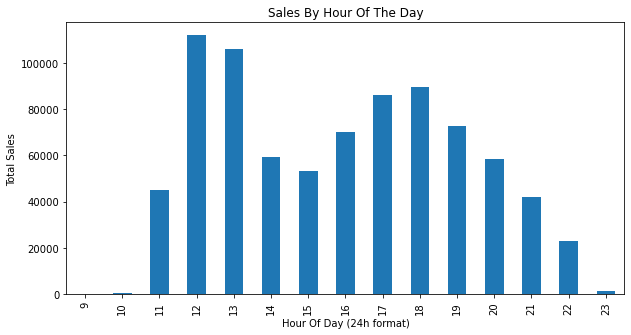

In [62]:
#Plot of a bar chart of total sales against Hours of Day
plt.figure(figsize=(10,5))
peak_hours.plot(kind="bar")
plt.title("Sales By Hour Of The Day")
plt.xlabel("Hour Of Day (24h format)")
plt.ylabel("Total Sales")

In [63]:
print("The Peak Hours Of Sales are 12th,13th,18th and 17th Hour according to the bar chart above")

The Peak Hours Of Sales are 12th,13th,18th and 17th Hour according to the bar chart above


## 7. Total Sales Made on Each Day of The Week

In [64]:
df["weekdays"] = df["date"].dt.day_name() #Creating the days columns according to the dates
df.head()

,pizza_id,pizza_type_id,size,price,name,category,ingredients,order_id,date,time,order_details_id,quantity,sales,ingredients_new,weekdays
0,bbq_ckn_s,bbq_ckn,S,12.75,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,...",6,2015-01-01,12,11,1,12.75,Barbecued Chicken| Red Peppers| Green Peppers|...,Thursday
1,bbq_ckn_s,bbq_ckn,S,12.75,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,...",102,2015-01-02,17,239,1,12.75,Barbecued Chicken| Red Peppers| Green Peppers|...,Friday
2,bbq_ckn_s,bbq_ckn,S,12.75,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,...",124,2015-01-02,20,294,1,12.75,Barbecued Chicken| Red Peppers| Green Peppers|...,Friday
3,bbq_ckn_s,bbq_ckn,S,12.75,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,...",194,2015-01-03,21,458,1,12.75,Barbecued Chicken| Red Peppers| Green Peppers|...,Saturday
4,bbq_ckn_s,bbq_ckn,S,12.75,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,...",208,2015-01-04,12,489,1,12.75,Barbecued Chicken| Red Peppers| Green Peppers|...,Sunday


In [66]:
# The sales per week days 
weekdays_sales = df.groupby("weekdays")["sales"].sum().reset_index()

print("The total sales made on each day of the week are: ")
weekdays_sales

The total sales made on each day of the week are: 


,weekdays,sales
0,Friday,136073.90
1,Monday,107329.55
2,Saturday,123182.40
3,Sunday,99203.50
4,Thursday,123528.50
5,Tuesday,114133.80
6,Wednesday,114408.40


# 7b. Day of the week Sales are made the most

In [67]:
# The day with most sales
weekdays_sales = weekdays_sales.sort_values(by= "sales", ascending=False)

weekdays_sales

,weekdays,sales
0,Friday,136073.90
4,Thursday,123528.50
2,Saturday,123182.40
6,Wednesday,114408.40
5,Tuesday,114133.80
1,Monday,107329.55
3,Sunday,99203.50


In [68]:
print(f"The day of the week when sales are made the most is (Friday), with (136073.90) sales made. ")

The day of the week when sales are made the most is (Friday), with (136073.90) sales made. 


## 8. Top 5 Best Selling Pizzas.

In [41]:
top5_pizzas = df.groupby("name")["quantity"].sum().reset_index().sort_values(by="quantity", ascending=False)
print(f"The top 5 best selling Pizzas according to their sales are:")
top5_pizzas.head()

The top 5 best selling Pizzas according to their sales are:


,name,quantity
7,The Classic Deluxe Pizza,2453
0,The Barbecue Chicken Pizza,2432
12,The Hawaiian Pizza,2422
20,The Pepperoni Pizza,2418
30,The Thai Chicken Pizza,2371


## 9. Sales Per Month


In [30]:
df["month"] = df["date"].dt.month_name()

In [32]:
monthly_sales = df.groupby("month")["sales"].sum().reset_index().sort_values(by="sales", ascending=False)
print("The Sales Per Month are: ")
monthly_sales

The Sales Per Month are: 


,month,sales
5,July,72557.90
8,May,71402.75
7,March,70397.10
9,November,70395.35
4,January,69793.30
0,April,68736.80
1,August,68278.25
6,June,68230.20
3,February,65159.60
2,December,64701.15


## 10. The Underperforming Pizzas

In [40]:
bottom5_pizzas = df.groupby("name")["quantity"].sum().reset_index().sort_values(by="quantity",ascending=False)
print("The 5 underperforming pizzas are: ")
bottom5_pizzas.tail(5)

The 5 underperforming pizzas are: 


,name,quantity
24,The Soppressata Pizza,961
28,The Spinach Supreme Pizza,950
3,The Calabrese Pizza,937
16,The Mediterranean Pizza,934
2,The Brie Carre Pizza,490
